Notebook illustrating the IF-DTW mining strategy of the paper. 

We only consider data from ILL18 for 2018. Note that you need to run the if_illustration.ipynb notebook first.

Note: Results may differ from the paper since we are only using data from 2018 and working with the final catalog only.

In [25]:
import obspy
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from joblib import load
from seismicif.datamod.loading_utils import (
    preproc_flow_annotations,
    extract_template,
    extract_split_flows,
)
from seismicif.dtw import template_dtw
from seismicif.metrics import (
    iou,
    est_thresholds,
    compute_statistics,
    extract_valid_segments,
)

First we extract templates from the high-confidence segments

In [26]:
folder = "../data/XP/2018/ILL18/EHZ.D/"
stream_paths = [folder + f for f in os.listdir(folder) if not f.startswith("._")]
stream_paths = np.array(sorted(stream_paths, key=lambda f: int(f.rsplit(".", 1)[-1])))

if_mod = load("../output/XP/if/models/ILL18_illustration.joblib")
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/flow_catalog.csv", index_col=0)
)
lower_conf_flows, high_conf_flows, all_flows = extract_split_flows(
    flows, "ILL18", 2018, 2018
)

templates = []
for i in range(high_conf_flows.shape[0]):
    t0 = high_conf_flows["start"][i]
    t1 = high_conf_flows["stop"][i]
    templates.append(extract_template(t0, t1, if_mod, stream_paths))
templates = np.array(templates)

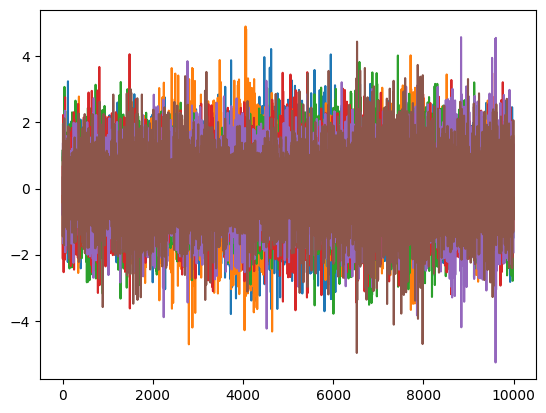

In [27]:
for tem in templates:
    plt.plot(tem)

When performing DTW we only consider segments flagged by the IF trigger. 

In [28]:
if_segments = preproc_flow_annotations(
    pd.read_csv("../output/XP/if/segments/ILL18_illustration.csv", index_col=0)
)

Compute the template DTW distances of IF segments w.r.t. all high-confidence segments.

In [32]:
try:
    dtw_dists = np.load("../output/XP/if_dtw/distances/ILL18_illustration.npy")

except (FileNotFoundError, OSError):
    dtw_dists = []
    for i in tqdm(range(if_segments.shape[0])):
        dtw_dists.append(
            template_dtw(
                if_segments["start"][i],
                if_segments["stop"][i],
                stream_paths,
                templates,
                if_mod,
            )
        )
    dtw_dists = np.array(dtw_dists)

    np.save("../output/XP/if_dtw/distances/ILL18_illustration", dtw_dists)

For each segment flagged by the IF trigger we compute the mean of the DTW distances w.r.t the templates. However, if a flagged segment overlaps with a high-confidence segment the DTW distance w.r.t the corresponding template is excluded.

We replace the IF segment anomaly score with the DTW score and sort the segments in increasing order.

In [33]:
dtw_scores = []

for i in range(dtw_dists.shape[0]):
    intersection, _, _ = iou(
        high_conf_flows, if_segments.loc[[i]].reset_index(drop=True)
    )
    high_conf_overlap = np.append(intersection[0], np.diff(intersection)) > 0
    dtw_scores.append(np.mean(dtw_dists[i, ~high_conf_overlap]))

dtw_segments = if_segments.copy()
dtw_segments["scores"] = dtw_scores
dtw_segments = dtw_segments.iloc[np.argsort(dtw_segments["scores"])].reset_index(
    drop=True
)

When calibrating the minimum detection length and score thresholds we compare (a) only detections overlapping with a high confidence segment or no lower-confidence segments with (b) high confidence segments.

In [34]:
valid_segments = extract_valid_segments(dtw_segments, lower_conf_flows, high_conf_flows)
# mode ="upper" to indicate that segments are sorted in ascending order of DTW score
iou_val, min_len, score_thres = est_thresholds(
    valid_segments, high_conf_flows, mode="upper"
)
print(f"detection iou: {100 * iou_val:.2f}%")

detection iou: 53.32%


In [35]:
detections = dtw_segments.copy()
start_times = np.array([pd.to_datetime(str(i)) for i in detections["start"]])
end_times = np.array([pd.to_datetime(str(i)) for i in detections["stop"]])
det_lens = np.array([i.total_seconds() for i in end_times - start_times])
detections = detections.assign(det_lens=det_lens)
detections = detections[
    (detections["scores"] < score_thres) & (detections["det_lens"] > min_len)
].reset_index(drop=True)
print(detections.head())

                         start                         stop       scores  \
0  2018-10-29T22:40:05.470000Z  2018-10-29T23:35:55.470000Z  5977.449394   
1  2018-10-29T15:15:55.470000Z  2018-10-29T16:58:25.470000Z  5978.635462   
2  2018-07-25T16:50:03.520019Z  2018-07-25T17:29:13.520019Z  6118.684793   
3  2018-10-29T14:25:05.470000Z  2018-10-29T15:05:55.470000Z  6298.216707   
4  2018-06-11T10:15:53.740003Z  2018-06-11T11:09:13.740003Z  6595.126678   

   det_lens  
0    3350.0  
1    6150.0  
2    2350.0  
3    2450.0  
4    3200.0  
